In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from graphviz import Digraph
from IPython.display import Image, display


In [ ]:
!apt-get install graphviz -y
!pip install graphviz




Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
!gdown --id  1278OcIoxha0swBUE26cWDH_laOMYREfk

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1278OcIoxha0swBUE26cWDH_laOMYREfk
To: /content/mushroom.zip
100% 141k/141k [00:00<00:00, 4.52MB/s]


In [ ]:
!unzip '/content/mushroom.zip'

Archive:  /content/mushroom.zip
  inflating: Index                   
  inflating: README                  
  inflating: agaricus-lepiota.data   
  inflating: agaricus-lepiota.names  
  inflating: expanded.Z              


In [ ]:
columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color',
    'population', 'habitat'
]
# Load data from the provided .data file
# Assuming the file is extracted or accessible as 'agaricus-lepiota.data'
df = pd.read_csv('/content/agaricus-lepiota.data',names=columns)

In [ ]:
print("--- Dataset Info ---")
print(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  sta

In [ ]:
#CHECK MISSING VALUES
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


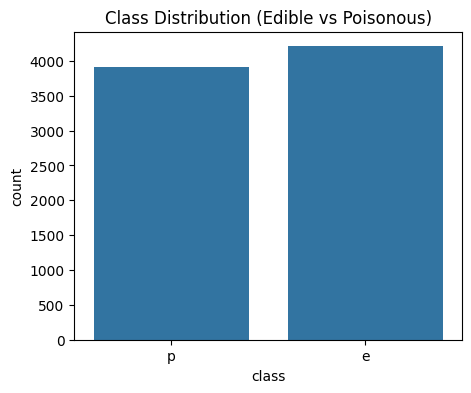

In [ ]:
#TARGET DISTRIBUTION (EDA)
plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution (Edible vs Poisonous)")
plt.show()

In [ ]:
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [ ]:
#Train test split
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6499, 22)
Testing set: (1625, 22)


In [ ]:
# Evaluate Random Forest with different n_estimators
n_estimators_list = [1, 50, 100, 150, 200, 250]
rf_accuracies = []

print("\n--- Random Forest Performance Comparison ---")
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rf_accuracies.append(acc)
    print(f"n_estimators = {n:3} | Accuracy: {acc:.4f}")



--- Random Forest Performance Comparison ---
n_estimators =   1 | Accuracy: 1.0000
n_estimators =  50 | Accuracy: 1.0000
n_estimators = 100 | Accuracy: 1.0000
n_estimators = 150 | Accuracy: 1.0000
n_estimators = 200 | Accuracy: 1.0000
n_estimators = 250 | Accuracy: 1.0000


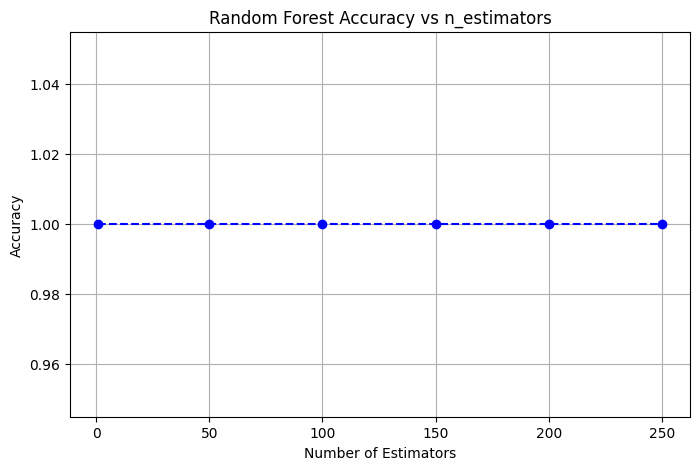

In [ ]:
# Plotting Random Forest Accuracy
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, rf_accuracies, marker='o', linestyle='--', color='b')
plt.title('Random Forest Accuracy vs n_estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
class DecisionTreeNumpy:
    def __init__(self, max_depth=None, feature_names=None):
        self.max_depth = max_depth
        self.tree = None
        self.feature_names = feature_names

    def entropy(self, y):
        if len(y) == 0: return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs))

    def information_gain(self, y, y1, y2):
        if len(y1) == 0 or len(y2) == 0: return 0
        p = len(y1) / len(y)
        return self.entropy(y) - p * self.entropy(y1) - (1 - p) * self.entropy(y2)

    def best_split(self, X, y):
        best_gain = -1
        best_feat, best_thresh = None, None
        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                y1 = y[X[:, feat_idx] <= thresh]
                y2 = y[X[:, feat_idx] > thresh]
                gain = self.information_gain(y, y1, y2)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat_idx, thresh
        return best_feat, best_thresh

    def build_tree(self, X, y, depth=0):
        if len(np.unique(y)) <= 1 or (self.max_depth and depth >= self.max_depth):
            return np.argmax(np.bincount(y)) if len(y) > 0 else 0

        feat_idx, thresh = self.best_split(X, y)
        if feat_idx is None: return np.argmax(np.bincount(y))

        left_idx = X[:, feat_idx] <= thresh
        right_idx = X[:, feat_idx] > thresh

        left_tree = self.build_tree(X[left_idx], y[left_idx], depth + 1)
        right_tree = self.build_tree(X[right_idx], y[right_idx], depth + 1)

        return {
            'feat_name': self.feature_names[feat_idx] if self.feature_names else feat_idx,
            'feat_idx': feat_idx, 'thresh': thresh,
            'left': left_tree, 'right': right_tree
        }

    def fit(self, X, y):
        # Ensure X and y are NumPy arrays
        X = X.values if isinstance(X, pd.DataFrame) else X
        y = y.values if isinstance(y, pd.Series) else y
        self.tree = self.build_tree(X, y)

    def predict(self, X):
        return np.array([self._predict(self.tree, x) for x in X])

    def _predict(self, node, x):
        if not isinstance(node, dict): return node
        if x[node['feat_idx']] <= node['thresh']:
            return self._predict(node['left'], x)
        return self._predict(node['right'], x)

    def visualize_tree(self, node=None, dot=None, parent=None, label=""):
        if dot is None: dot = Digraph()
        node = node or self.tree
        node_id = str(id(node))

        if isinstance(node, dict):
            node_label = f"{node['feat_name']} <= {node['thresh']}"
            dot.node(node_id, node_label)
            if parent: dot.edge(parent, node_id, label=label)
            self.visualize_tree(node['left'], dot, node_id, "True")
            self.visualize_tree(node['right'], dot, node_id, "False")
        else:
            leaf_label = "Edible" if node == 0 else "Poisonous"
            dot.node(node_id, leaf_label, shape='box', color='green' if node==0 else 'red')
            if parent: dot.edge(parent, node_id, label=label)
        return dot

# --- Training the Custom Tree ---

feature_names = X.columns.tolist()
custom_dt = DecisionTreeNumpy(max_depth=3, feature_names=feature_names)
custom_dt.fit(X_train.values, y_train.values)
y_pred_custom = custom_dt.predict(X_test.values)

print("\n--- Custom Numpy Decision Tree Metrics ---")
print(f"Precision: {precision_score(y_test, y_pred_custom, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_custom, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_custom, average='macro'):.4f}")

# Visualization

try:
    dot_graph = custom_dt.visualize_tree()
    dot_graph.render('mushroom_tree', format='png')
    display(Image('mushroom_tree.png'))
except Exception as e:
    print("\nVisualization skipped: Ensure Graphviz is installed.")


--- Custom Numpy Decision Tree Metrics ---
Precision: 0.9494
Recall:    0.9499
F1-score:  0.9489

Visualization skipped: Ensure Graphviz is installed.


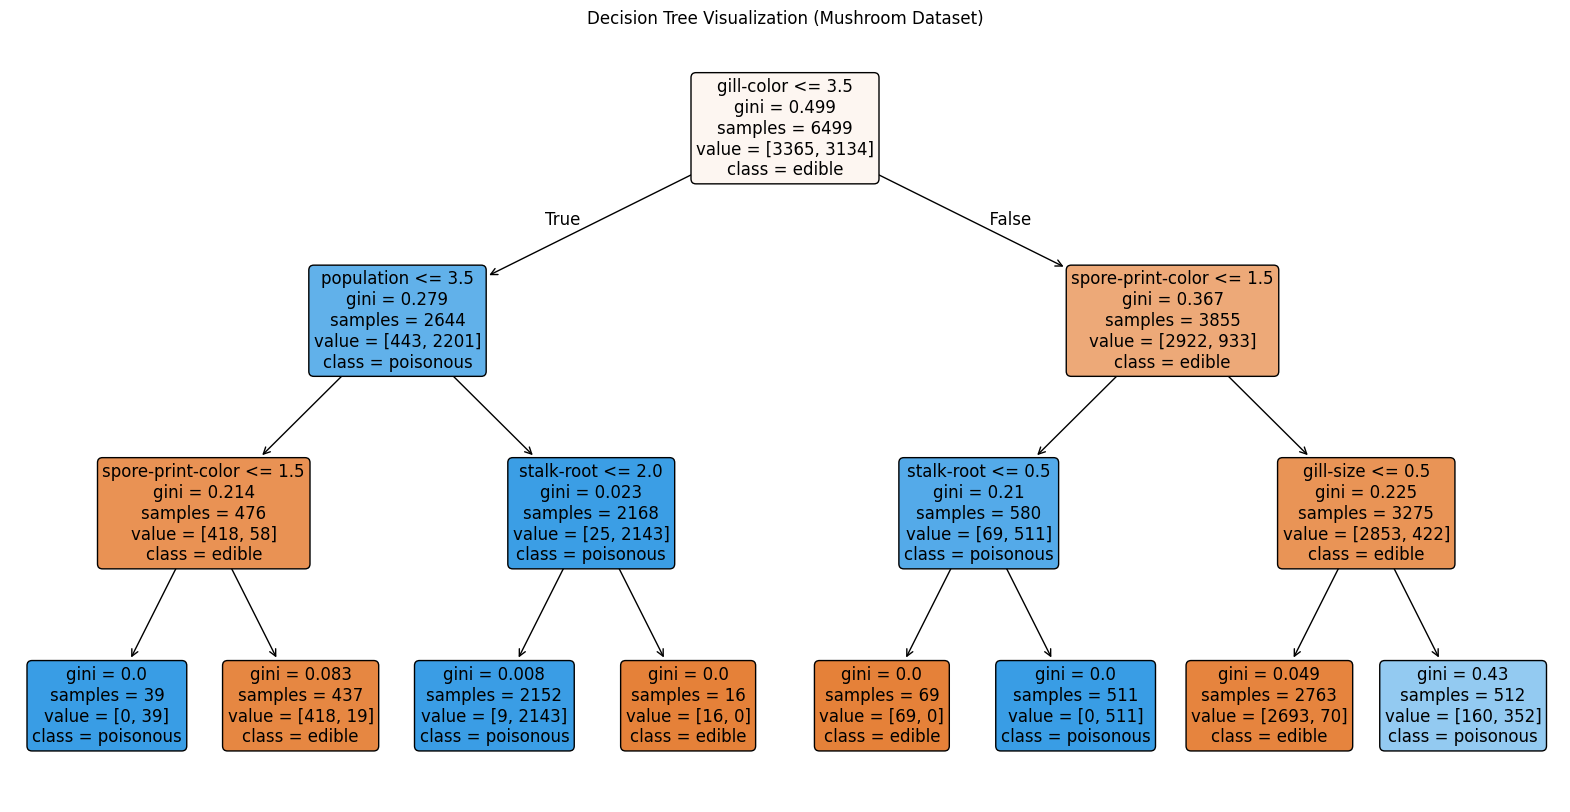

In [ ]:

dt_sklearn = DecisionTreeClassifier(max_depth=3)
dt_sklearn.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
tree.plot_tree(dt_sklearn,
               feature_names=X.columns,
               class_names=['edible', 'poisonous'],
               filled=True,
               rounded=True,
               fontsize=12)

plt.title('Decision Tree Visualization (Mushroom Dataset)')
plt.show()

In [ ]:
# FINAL COMPARISON
# =========================
dt_accuracy = accuracy_score(y_test, y_pred_custom)

results = pd.DataFrame({
    "Model": ["Decision Tree"] + [f"Random Forest ({n})" for n in n_estimators_list],
    "Accuracy": [dt_accuracy] + rf_accuracies
})

results

,Model,Accuracy
0,Decision Tree,0.948923
1,Random Forest (1),1.000000
2,Random Forest (50),1.000000
3,Random Forest (100),1.000000
4,Random Forest (150),1.000000
5,Random Forest (200),1.000000
6,Random Forest (250),1.000000
